In [2]:
import os

In [3]:
os.chdir('../')

In [4]:
%pwd

'c:\\Users\\hulkh\\Desktop\\Python\\supplier_clustering\\Supplier_clustering'

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('artifacts/feature_engineering/engineered_data.csv')
df

,supplier_id,price_competitiveness,cost_variability,total_spend,order_frequency,average_delivery_delay,quality_rejection_rate,on_time_delivery_rate,average_late_days
0,SUP-001,0.972818,0.090826,2180952.04,107,0.121495,0.009346,0.934579,0.121495
1,SUP-002,0.970539,0.089811,83912380.83,4172,0.257910,0.014621,0.891419,0.257910
2,SUP-003,1.090915,0.088498,10388962.85,456,0.370614,0.017544,0.868421,0.370614
3,SUP-004,1.051534,0.084760,1426125.23,67,0.208955,0.000000,0.910448,0.208955
4,SUP-005,1.099693,0.082324,2972062.85,127,0.330709,0.007874,0.874016,0.330709
...,...,...,...,...,...,...,...,...,...
101,SUP-102,0.908411,0.060653,5689957.03,710,0.239437,0.023944,0.911268,0.239437
102,SUP-103,1.071268,0.063343,1482987.60,156,0.384615,0.012821,0.858974,0.384615
103,SUP-104,1.056981,0.054959,188833.89,21,0.047619,0.000000,0.952381,0.047619
104,SUP-105,1.079207,0.064942,6606243.68,708,0.237288,0.008475,0.895480,0.237288


In [7]:
df.describe()

,price_competitiveness,cost_variability,total_spend,order_frequency,average_delivery_delay,quality_rejection_rate,on_time_delivery_rate,average_late_days
count,106.000000,106.000000,1.060000e+02,106.000000,106.000000,106.000000,106.000000,106.000000
mean,0.993467,0.080349,3.879088e+06,444.603774,0.862463,0.017964,0.836586,0.862463
std,0.066226,0.036096,9.194998e+06,798.817873,2.406002,0.027652,0.203117,2.406002
min,0.860772,0.014846,1.638747e+04,3.000000,0.000000,0.000000,0.000000,0.000000
25%,0.942912,0.053354,1.387961e+05,37.250000,0.205151,0.000000,0.869916,0.205151
50%,1.002002,0.065603,8.974078e+05,127.500000,0.261013,0.011528,0.893593,0.261013
75%,1.044056,0.111058,4.492715e+06,539.750000,0.332677,0.019713,0.902629,0.332677
max,1.161405,0.185699,8.391238e+07,5384.000000,11.005181,0.160000,1.000000,11.005181


In [8]:
skewness = df.skew(numeric_only=True)
skewness

price_competitiveness    -0.083209
cost_variability          0.707082
total_spend               6.635875
order_frequency           3.717419
average_delivery_delay    3.864803
quality_rejection_rate    3.011462
on_time_delivery_rate    -3.445044
average_late_days         3.864803
dtype: float64

In [9]:
feature_columns = [
    "price_competitiveness",
    "cost_variability",
    "total_spend",
    "order_frequency",
    "average_late_days",
    "average_delivery_delay",
    "quality_rejection_rate",
    "on_time_delivery_rate"
]

df1 = df[feature_columns]
supplier_ids = df["supplier_id"]

In [10]:
corr = df1.corr()
corr

,price_competitiveness,cost_variability,total_spend,order_frequency,average_late_days,average_delivery_delay,quality_rejection_rate,on_time_delivery_rate
price_competitiveness,1.000000,-0.042901,0.059236,0.055424,-0.065270,-0.065270,-0.005787,0.054397
cost_variability,-0.042901,1.000000,0.184900,0.032602,0.475892,0.475892,0.507433,-0.464426
total_spend,0.059236,0.184900,1.000000,0.728739,0.009069,0.009069,0.051369,0.005467
order_frequency,0.055424,0.032602,0.728739,1.000000,0.024518,0.024518,0.078642,0.000081
average_late_days,-0.065270,0.475892,0.009069,0.024518,1.000000,1.000000,0.874685,-0.973648
average_delivery_delay,-0.065270,0.475892,0.009069,0.024518,1.000000,1.000000,0.874685,-0.973648
quality_rejection_rate,-0.005787,0.507433,0.051369,0.078642,0.874685,0.874685,1.000000,-0.834632
on_time_delivery_rate,0.054397,-0.464426,0.005467,0.000081,-0.973648,-0.973648,-0.834632,1.000000


In [11]:
for col in df1.columns:

    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df1[
        (df1[col] < lower_bound) |
        (df1[col] > upper_bound)
    ]

    print(f"\n{col}")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")
    print(f"Number of outliers: {len(outliers)}")


price_competitiveness
Lower bound: 0.7911948803990645
Upper bound: 1.1957727544315195
Number of outliers: 0

cost_variability
Lower bound: -0.03320159186912794
Upper bound: 0.19761338617506435
Number of outliers: 0

total_spend
Lower bound: -6392081.924999999
Upper bound: 11023592.895
Number of outliers: 11

order_frequency
Lower bound: -716.5
Upper bound: 1293.5
Number of outliers: 10

average_late_days
Lower bound: 0.013862820291935224
Upper bound: 0.5239657723917679
Number of outliers: 16

average_delivery_delay
Lower bound: 0.013862820291935224
Upper bound: 0.5239657723917679
Number of outliers: 16

quality_rejection_rate
Lower bound: -0.0295700187969924
Upper bound: 0.049283364661654
Number of outliers: 7

on_time_delivery_rate
Lower bound: 0.8208463881334005
Upper bound: 0.9516982825172637
Number of outliers: 20


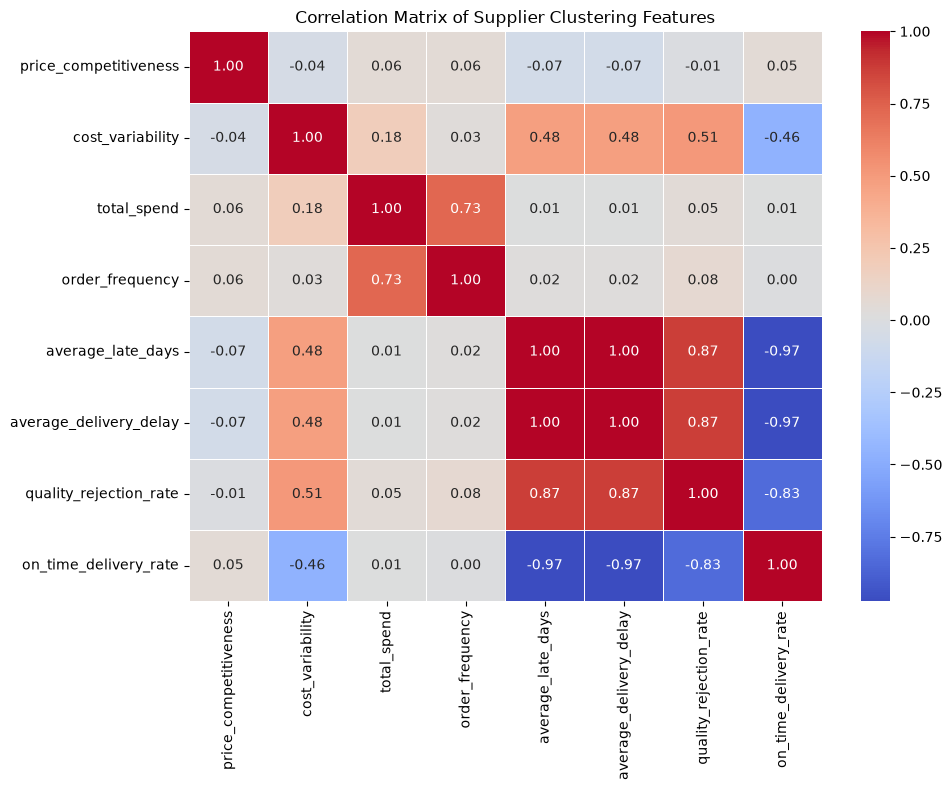

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Supplier Clustering Features")
plt.tight_layout()
plt.show()

| Feature                  | Outliers |   Skewness | What it tells us                             | Decision               |
| ------------------------ | -------: | ---------: | -------------------------------------------- | ---------------------- |
| `price_competitiveness`  |        0 |     -0.083 | Very well behaved                            | Keep as-is             |
| `cost_variability`       |        0 |      0.707 | Moderately right-skewed, but no IQR outliers | Probably keep          |
| `total_spend`            |       11 |  **6.636** | Extremely right-skewed                       | Consider log transform |
| `order_frequency`        |       10 |  **3.717** | Strongly right-skewed                        | Consider log transform |
| `average_delivery_delay` |       16 |  **3.865** | Strongly right-skewed                        | Redundant anyway       |
| `quality_rejection_rate` |        7 |  **3.011** | Strongly right-skewed                        | Investigate            |
| `on_time_delivery_rate`  |       20 | **-3.445** | Strongly left-skewed                         | Redundant anyway       |
| `average_late_days`      |       16 |  **3.865** | Strongly right-skewed                        | Investigate            |

In [13]:
df2 = df1.copy()

Very high correlation pairs (correlation coefficient) are:
- `average_late_days` and `average_delivery_delay`
- `average_late_days` and `on_time_delivery_rate`
- So dropping `average_delivery_delay` and `on_time_delivery_rate` because `average_late_days` is a much more important feature

In [14]:
df2.drop(columns =['average_delivery_delay','on_time_delivery_rate'], inplace=True)

In [15]:
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
price_competitiveness,106.0,9.934674e-01,6.622584e-02,0.860772,0.942912,1.002002,1.044056e+00,1.161405e+00
cost_variability,106.0,8.034917e-02,3.609566e-02,0.014846,0.053354,0.065603,1.110578e-01,1.856988e-01
total_spend,106.0,3.879088e+06,9.194998e+06,16387.470000,138796.132500,897407.805000,4.492715e+06,8.391238e+07
order_frequency,106.0,4.446038e+02,7.988179e+02,3.000000,37.250000,127.500000,5.397500e+02,5.384000e+03
average_late_days,106.0,8.624630e-01,2.406002e+00,0.000000,0.205151,0.261013,3.326772e-01,1.100518e+01
quality_rejection_rate,106.0,1.796399e-02,2.765152e-02,0.000000,0.000000,0.011528,1.971335e-02,1.600000e-01


In [16]:
df2.skew().sort_values()

price_competitiveness    -0.083209
cost_variability          0.707082
quality_rejection_rate    3.011462
order_frequency           3.717419
average_late_days         3.864803
total_spend               6.635875
dtype: float64

- `total_spend`       → strongly right-skewed
- `order_frequency`   → strongly right-skewed
- `average_late_days` → strongly right-skewed
- `quality_rejection_rate` → strongly right-skewed

In [18]:
Q1 = df["total_spend"].quantile(0.25)
Q3 = df["total_spend"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["total_spend"] < lower_bound) |
    (df["total_spend"] > upper_bound)
]

print(outliers[["supplier_id", "total_spend"]])

   supplier_id  total_spend
1      SUP-002  83912380.83
5      SUP-006  13568470.46
7      SUP-008  12990183.01
15     SUP-016  24672186.74
24     SUP-025  16010733.91
27     SUP-028  21206582.00
31     SUP-032  11105069.03
33     SUP-034  12181112.88
35     SUP-036  11943662.41
56     SUP-057  11565869.77
94     SUP-095  12149653.63


In [19]:
corr_2 = df2.corr()
corr_2

,price_competitiveness,cost_variability,total_spend,order_frequency,average_late_days,quality_rejection_rate
price_competitiveness,1.000000,-0.042901,0.059236,0.055424,-0.065270,-0.005787
cost_variability,-0.042901,1.000000,0.184900,0.032602,0.475892,0.507433
total_spend,0.059236,0.184900,1.000000,0.728739,0.009069,0.051369
order_frequency,0.055424,0.032602,0.728739,1.000000,0.024518,0.078642
average_late_days,-0.065270,0.475892,0.009069,0.024518,1.000000,0.874685
quality_rejection_rate,-0.005787,0.507433,0.051369,0.078642,0.874685,1.000000


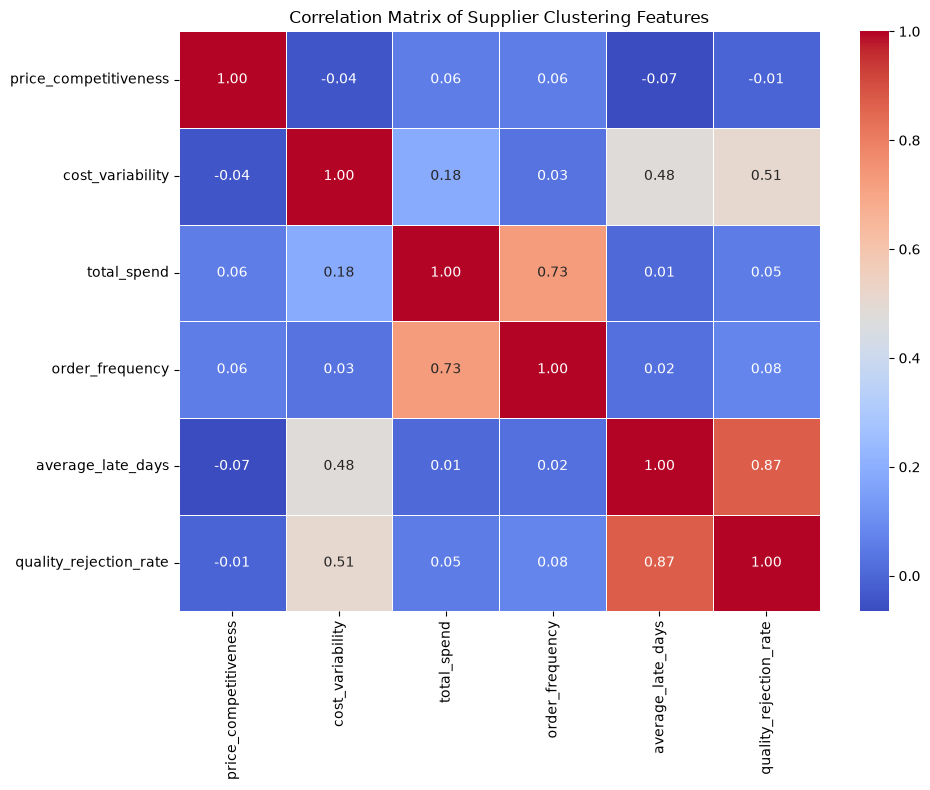

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_2,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Supplier Clustering Features")
plt.tight_layout()
plt.show()

In [45]:
# entity

from dataclasses import dataclass
from pathlib import Path

#entity
@dataclass(frozen=True)
class FeatureSelectionConfig:
    # These values are set in the config.yaml file and passed to the FeatureSelectionConfig class
    root_dir: Path  # where the selected features will be saved
    input_data_path: Path  # where the input data for feature selection is located

In [46]:
# configuration manager
from src.Supplier_clustering.constants import *
from src.Supplier_clustering.utils.common import read_yaml, create_directories

In [47]:
class ConfigurationManager:
    def __init__(
        self,
        config_filepath = CONFIG_FILE_PATH,
        params_filepath = PARAMS_FILE_PATH,
        schema_filepath = SCHEMA_FILE_PATH):

        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)
        self.schema = read_yaml(schema_filepath)

        create_directories([self.config.artifacts_root])


    
    def get_feature_selection_config(self) -> FeatureSelectionConfig:

        config = self.config.feature_selection

        feature_selection_config = FeatureSelectionConfig(
        root_dir=Path(config.root_dir),
        input_data_path=Path(config.input_data_path)
    )

        return feature_selection_config

In [48]:
from src.Supplier_clustering.utils.logger import logger

In [49]:
class FeatureSelection:

    def __init__(self, config: FeatureSelectionConfig):
        self.config = config

    # ---------------------------------------------------------
    # Descriptive Statistics
    # ---------------------------------------------------------

    def analyze_descriptive_statistics(
        self,
        df: pd.DataFrame
    ) -> pd.DataFrame:

        return df.describe().T

    # ---------------------------------------------------------
    # Skewness
    # ---------------------------------------------------------

    def analyze_skewness(
        self,
        df: pd.DataFrame
    ) -> pd.Series:

        return df.skew().sort_values()

    # ---------------------------------------------------------
    # Outlier Detection
    # ---------------------------------------------------------

    def detect_outliers(
        self,
        df: pd.DataFrame
    ) -> dict:

        outlier_results = {}

        for col in df.columns:

            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)

            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers = df[
                (df[col] < lower_bound) |
                (df[col] > upper_bound)
            ]

            outlier_results[col] = {
                "Q1": Q1,
                "Q3": Q3,
                "IQR": IQR,
                "lower_bound": lower_bound,
                "upper_bound": upper_bound,
                "number_of_outliers": len(outliers)
            }

        return outlier_results

    # ---------------------------------------------------------
    # Correlation Analysis
    # ---------------------------------------------------------

    def analyze_correlation(
        self,
        df: pd.DataFrame
    ) -> pd.DataFrame:

        return df.corr()

    # ---------------------------------------------------------
    # Final Feature Selection
    # ---------------------------------------------------------

    def select_features(
        self,
        df: pd.DataFrame
    ) -> pd.DataFrame:

        selected_features = [
            "price_competitiveness",
            "cost_variability",
            "total_spend",
            "order_frequency",
            "quality_rejection_rate",
            "average_late_days"
        ]

        return df[selected_features]

    # ---------------------------------------------------------
    # Main Feature Selection Pipeline
    # ---------------------------------------------------------

    def initiate_feature_selection(self) :

        df = pd.read_csv(self.config.input_data_path)

        logger.info("Starting feature selection")

        # Create feature-selection artifact directory
        self.config.root_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        # -----------------------------------------------------
        # Keep supplier_id as identifier
        # -----------------------------------------------------

        supplier_ids = df[["supplier_id"]].copy()

        # -----------------------------------------------------
        # Remove supplier_id from feature analysis
        # -----------------------------------------------------

        feature_data = df.drop(
            columns=["supplier_id"]
        )

        # -----------------------------------------------------
        # 1. Descriptive Statistics
        # -----------------------------------------------------

        statistics = self.analyze_descriptive_statistics(
            feature_data
        )

        statistics.to_csv(
            self.config.root_dir /
            "descriptive_statistics.csv"
        )

        # -----------------------------------------------------
        # 2. Skewness
        # -----------------------------------------------------

        skewness = self.analyze_skewness(
            feature_data
        )

        skewness.to_csv(
            self.config.root_dir /
            "skewness.csv",
            header=["skewness"]
        )

        # -----------------------------------------------------
        # 3. Outlier Analysis
        # -----------------------------------------------------

        outliers = self.detect_outliers(
            feature_data
        )

        outlier_df = pd.DataFrame(
            outliers
        ).T

        outlier_df.to_csv(
            self.config.root_dir /
            "outlier_analysis.csv"
        )

        # -----------------------------------------------------
        # 4. Correlation Analysis
        # -----------------------------------------------------

        correlation = self.analyze_correlation(
            feature_data
        )

        correlation.to_csv(
            self.config.root_dir /
            "correlation_matrix.csv"
        )

        # -----------------------------------------------------
        # 5. Select Final Features
        # -----------------------------------------------------

        selected_features = self.select_features(
            feature_data
        )

        # -----------------------------------------------------
        # Add supplier_id back as identifier
        # -----------------------------------------------------

        final_data = pd.concat(
            [
                supplier_ids,
                selected_features
            ],
            axis=1
        )

        # -----------------------------------------------------
        # 6. Save Final Selected Dataset
        # -----------------------------------------------------

        final_data.to_csv(
                    os.path.join(
                        self.config.root_dir,
                        "selected_features.csv"
                    ),
                    index=False
                )

        logger.info(
            "Feature selection completed successfully"
        )

        logger.info(
            f"Final selected features: "
            f"{list(selected_features.columns)}"
        )

        logger.info(
            f"Final dataset shape: {final_data.shape}"
        )

        print("\nFinal Selected Features:")
        print(selected_features.columns.tolist())

        print("\nFinal Dataset:")
        print(final_data.head())

        print("\nFinal Dataset Shape:")
        print(final_data.shape)

        return final_data

In [50]:
#pipeline
try:
    config = ConfigurationManager()
    feature_selection_config = config.get_feature_selection_config()
    feature_selection = FeatureSelection(config=feature_selection_config)
    feature_selection.initiate_feature_selection()
except Exception as e:
    raise e

[2026-09-01 16:15:22,193: INFO: common: yaml file: config\config.yaml loaded successfully]
[2026-09-01 16:15:22,196: INFO: common: yaml file: params.yaml loaded successfully]
[2026-09-01 16:15:22,199: INFO: common: yaml file: schema.yaml loaded successfully]
[2026-09-01 16:15:22,200: INFO: common: created directory at: artifacts]
[2026-09-01 16:15:22,225: INFO: 150248964: Starting feature selection]
[2026-09-01 16:15:22,263: INFO: 150248964: Feature selection completed successfully]
[2026-09-01 16:15:22,263: INFO: 150248964: Final selected features: ['price_competitiveness', 'cost_variability', 'total_spend', 'order_frequency', 'quality_rejection_rate', 'average_late_days']]
[2026-09-01 16:15:22,263: INFO: 150248964: Final dataset shape: (106, 7)]

Final Selected Features:
['price_competitiveness', 'cost_variability', 'total_spend', 'order_frequency', 'quality_rejection_rate', 'average_late_days']

Final Dataset:
  supplier_id  price_competitiveness  cost_variability  total_spend  \
0 

In [ ]:
results = df1[["supplier_id"]].copy()

results["cluster"] = kmeans.labels_